In [11]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

### Imports

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import warnings
warnings.filterwarnings('ignore')

### Loading Datasets

In [14]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

In [15]:
print(f"The shape of train set: {train_df.shape}")
print(f"The shape of test set: {test_df.shape}")

The shape of train set: (10000, 9)
The shape of test set: (3320, 8)


In [16]:
print(f"The columns of train dataset: {list(train_df.columns)}")
print(f"The columns of test dataset: {list(test_df.columns)}")

The columns of train dataset: ['id', 'area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony', 'price']
The columns of test dataset: ['id', 'area_type', 'availability', 'location', 'size', 'total_sqft', 'bath', 'balcony']


In [17]:
train_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,type_I,Ready To Move,Banashankari 2 nd Stage,3 BHK,1030.0,2.0,2.0,77.25
1,1,type_I,Ready To Move,Balagere,2 BHK,1210.0,2.0,1.0,83.00
2,2,type_I,17-Oct,Banashankari Stage V,3 BHK,1540.0,3.0,2.0,48.51
3,3,type_I,Ready To Move,Thigalarapalya,3 BHK,1830.0,4.0,2.0,135.00
4,4,type_III,Ready To Move,arudi,3 Bedroom,NaN,2.0,0.0,80.00


In [18]:
test_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,type_II,Ready To Move,Banjara Layout,2 Bedroom,1050.0,2.0,1.0
1,1,type_I,Ready To Move,Rajiv Nagar,3 BHK,1690.0,3.0,1.0
2,2,type_II,Ready To Move,Hebbal,2 BHK,1100.0,2.0,1.0
3,3,type_III,Ready To Move,Munnekollal,6 Bedroom,1200.0,4.0,2.0
4,4,type_II,18-Apr,Choodasandra,4 Bedroom,2429.0,3.0,1.0


### Data Preprocessing

#### Find data types of each column

In [19]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  object 
 2   availability  10000 non-null  object 
 3   location      9999 non-null   object 
 4   size          9987 non-null   object 
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 703.3+ KB


In [20]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3320 non-null   int64  
 1   area_type     3320 non-null   object 
 2   availability  3320 non-null   object 
 3   location      3320 non-null   object 
 4   size          3317 non-null   object 
 5   total_sqft    3307 non-null   float64
 6   bath          3311 non-null   float64
 7   balcony       3186 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 207.6+ KB


#### Describe numerical column

In [21]:
train_df.describe()

,id,total_sqft,bath,balcony,price
count,10000.00000,9967.000000,9936.000000,9525.000000,10000.000000
mean,4999.50000,1570.095822,2.692029,1.585302,113.275879
std,2886.89568,1302.566836,1.274172,0.814347,151.802643
min,0.00000,1.000000,1.000000,0.000000,8.000000
25%,2499.75000,1100.000000,2.000000,1.000000,50.000000
50%,4999.50000,1279.000000,2.000000,2.000000,72.000000
75%,7499.25000,1682.500000,3.000000,2.000000,120.000000
max,9999.00000,52272.000000,18.000000,3.000000,3600.000000


#### Preprocessing - Encode categorical features

#### Encode Area column

In [22]:
(train_df["area_type"].value_counts())

area_type
type_I      6589
type_II     1832
type_III    1515
type_IV       64
Name: count, dtype: int64

In [23]:
# Change the Field area_type into numerical column
# type I mapped to 1, II mapped to 2, III maped to 3 and IV is mapped to 4.
from sklearn.preprocessing import OrdinalEncoder

area_type_categories = [["type_I", "type_II", "type_III", "type_IV"]]

area_ord_enc = OrdinalEncoder(categories = area_type_categories)

In [24]:
train_df["area_type"] = area_ord_enc.fit_transform(train_df[["area_type"]]) + 1

In [25]:
test_df["area_type"] = area_ord_enc.transform(test_df[["area_type"]]) + 1

In [26]:
test_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,2.0,Ready To Move,Banjara Layout,2 Bedroom,1050.0,2.0,1.0
1,1,1.0,Ready To Move,Rajiv Nagar,3 BHK,1690.0,3.0,1.0
2,2,2.0,Ready To Move,Hebbal,2 BHK,1100.0,2.0,1.0
3,3,3.0,Ready To Move,Munnekollal,6 Bedroom,1200.0,4.0,2.0
4,4,2.0,18-Apr,Choodasandra,4 Bedroom,2429.0,3.0,1.0


In [27]:
train_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,1.0,Ready To Move,Banashankari 2 nd Stage,3 BHK,1030.0,2.0,2.0,77.25
1,1,1.0,Ready To Move,Balagere,2 BHK,1210.0,2.0,1.0,83.00
2,2,1.0,17-Oct,Banashankari Stage V,3 BHK,1540.0,3.0,2.0,48.51
3,3,1.0,Ready To Move,Thigalarapalya,3 BHK,1830.0,4.0,2.0,135.00
4,4,3.0,Ready To Move,arudi,3 Bedroom,NaN,2.0,0.0,80.00


In [28]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  float64
 2   availability  10000 non-null  object 
 3   location      9999 non-null   object 
 4   size          9987 non-null   object 
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(5), int64(1), object(3)
memory usage: 703.3+ KB


#### Enocode availability column

In [29]:
print(train_df["availability"].value_counts().index.to_list())

['Ready To Move', '18-Dec', '18-May', '18-Apr', '18-Aug', '19-Dec', '18-Jul', '18-Mar', '20-Dec', '18-Jun', '21-Dec', '19-Mar', '18-Feb', '18-Nov', '18-Oct', '19-Jan', '19-Jun', '18-Jan', '18-Sep', '19-Jul', '17-Dec', '20-Jan', '19-Sep', '17-Oct', '21-Jun', '19-Aug', '22-Jun', 'Immediate Possession', '20-Aug', '19-Apr', '17-Jun', '17-Jul', '19-Oct', '22-May', '21-Jan', '21-Mar', '17-Nov', '17-Sep', '17-Aug', '20-Jun', '21-May', '22-Dec', '20-Oct', '17-May', '19-Nov', '19-May', '17-Apr', '21-Jul', '21-Feb', '20-Sep', '17-Mar', '22-Jan', '21-Oct', '21-Sep', '21-Aug', '20-Jul', '21-Nov', '16-Sep', '16-Dec', '20-Apr', '20-Mar', '19-Feb', '17-Feb', '20-Feb', '16-Mar', '22-Mar', '15-Nov', '15-Oct', '17-Jan', '14-Jul', '20-May', '16-Jul', '15-Jun', '20-Nov', '16-Oct', '15-Dec']


In [30]:
# The column availability not going to contribute that much for prediction, since all most all the
# data is Ready to move state. Even though, I encode this into two bins.
# One is Ready to move and other is future. Usually Ready to move get higher price, than future
# availability

def encode_availability(avail):
    if avail in ["Ready To Move", "Immediate Possession"]:
        return 1.0 
    else:
        return 0.0 

train_df["availability"] = train_df["availability"].apply(encode_availability)

In [31]:
train_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,1.0,1.0,Banashankari 2 nd Stage,3 BHK,1030.0,2.0,2.0,77.25
1,1,1.0,1.0,Balagere,2 BHK,1210.0,2.0,1.0,83.00
2,2,1.0,0.0,Banashankari Stage V,3 BHK,1540.0,3.0,2.0,48.51
3,3,1.0,1.0,Thigalarapalya,3 BHK,1830.0,4.0,2.0,135.00
4,4,3.0,1.0,arudi,3 Bedroom,NaN,2.0,0.0,80.00


In [32]:
test_df["availability"] = test_df["availability"].apply(encode_availability)

In [33]:
test_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,2.0,1.0,Banjara Layout,2 Bedroom,1050.0,2.0,1.0
1,1,1.0,1.0,Rajiv Nagar,3 BHK,1690.0,3.0,1.0
2,2,2.0,1.0,Hebbal,2 BHK,1100.0,2.0,1.0
3,3,3.0,1.0,Munnekollal,6 Bedroom,1200.0,4.0,2.0
4,4,2.0,0.0,Choodasandra,4 Bedroom,2429.0,3.0,1.0


In [34]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3320 non-null   int64  
 1   area_type     3320 non-null   float64
 2   availability  3320 non-null   float64
 3   location      3320 non-null   object 
 4   size          3317 non-null   object 
 5   total_sqft    3307 non-null   float64
 6   bath          3311 non-null   float64
 7   balcony       3186 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 207.6+ KB


In [35]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  float64
 2   availability  10000 non-null  float64
 3   location      9999 non-null   object 
 4   size          9987 non-null   object 
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 703.3+ KB


#### Encode location column and handle missing values

In [36]:
train_df["location"].value_counts()

location
Whitefield           403
Sarjapur  Road       301
Electronic City      226
Kanakpura Road       209
Thanisandra          183
                    ... 
Marathalli bridge      1
Punappa Layout         1
t.c palya              1
Ashraya Layout         1
Subash Nagar           1
Name: count, Length: 1185, dtype: int64

In [37]:
train_df["location"] = train_df["location"].str.strip().str.title()

In [38]:
test_df["location"] = test_df["location"].str.strip().str.title()

In [39]:
train_df["location"] = train_df["location"].fillna("Other")
test_df["location"] = test_df["location"].fillna("Other")

In [40]:
train_df_loc_counts = train_df["location"].value_counts()
rare_loc_index = train_df_loc_counts[train_df_loc_counts<=10].index
train_df["location"] = train_df["location"].apply(lambda x: "Other" if x in rare_loc_index else x)

In [41]:
test_df_loc_counts = test_df["location"].value_counts()
test_rare_loc_index = test_df_loc_counts[test_df_loc_counts<=10].index
test_df["location"] = test_df["location"].apply(lambda x: "Other" if x in test_rare_loc_index else x)

In [42]:
train_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,1.0,1.0,Other,3 BHK,1030.0,2.0,2.0,77.25
1,1,1.0,1.0,Balagere,2 BHK,1210.0,2.0,1.0,83.00
2,2,1.0,0.0,Other,3 BHK,1540.0,3.0,2.0,48.51
3,3,1.0,1.0,Thigalarapalya,3 BHK,1830.0,4.0,2.0,135.00
4,4,3.0,1.0,Other,3 Bedroom,NaN,2.0,0.0,80.00


In [43]:
test_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,2.0,1.0,Other,2 Bedroom,1050.0,2.0,1.0
1,1,1.0,1.0,Other,3 BHK,1690.0,3.0,1.0
2,2,2.0,1.0,Hebbal,2 BHK,1100.0,2.0,1.0
3,3,3.0,1.0,Munnekollal,6 Bedroom,1200.0,4.0,2.0
4,4,2.0,0.0,Other,4 Bedroom,2429.0,3.0,1.0


In [44]:
# encode the location feature using avg price in that location
location_mean_price = train_df.groupby("location")["price"].mean()

In [45]:
train_df["location"] = train_df["location"].map(location_mean_price)
test_df["location"] = test_df["location"].map(location_mean_price)

In [46]:
train_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,1.0,1.0,141.489097,3 BHK,1030.0,2.0,2.0,77.25
1,1,1.0,1.0,62.616719,2 BHK,1210.0,2.0,1.0,83.00
2,2,1.0,0.0,141.489097,3 BHK,1540.0,3.0,2.0,48.51
3,3,1.0,1.0,149.929184,3 BHK,1830.0,4.0,2.0,135.00
4,4,3.0,1.0,141.489097,3 Bedroom,NaN,2.0,0.0,80.00


In [47]:
test_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,2.0,1.0,141.489097,2 Bedroom,1050.0,2.0,1.0
1,1,1.0,1.0,141.489097,3 BHK,1690.0,3.0,1.0
2,2,2.0,1.0,160.050154,2 BHK,1100.0,2.0,1.0
3,3,3.0,1.0,85.494615,6 Bedroom,1200.0,4.0,2.0
4,4,2.0,0.0,141.489097,4 Bedroom,2429.0,3.0,1.0


In [48]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  float64
 2   availability  10000 non-null  float64
 3   location      10000 non-null  float64
 4   size          9987 non-null   object 
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 703.3+ KB


In [49]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3320 non-null   int64  
 1   area_type     3320 non-null   float64
 2   availability  3320 non-null   float64
 3   location      3320 non-null   float64
 4   size          3317 non-null   object 
 5   total_sqft    3307 non-null   float64
 6   bath          3311 non-null   float64
 7   balcony       3186 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 207.6+ KB


#### Encode Size column and handle missing values

In [50]:
train_df["size"].value_counts().index

Index(['2 BHK', '3 BHK', '4 Bedroom', '4 BHK', '3 Bedroom', '1 BHK',
       '2 Bedroom', '5 Bedroom', '6 Bedroom', '1 Bedroom', '7 Bedroom',
       '8 Bedroom', '5 BHK', '9 Bedroom', '6 BHK', '1 RK', '7 BHK',
       '10 Bedroom', '9 BHK', '8 BHK', '10 BHK', '11 BHK', '16 BHK',
       '12 Bedroom', '13 BHK', '14 BHK', '18 Bedroom'],
      dtype='object', name='size')

In [51]:
def encode_house_size(room):
    if room is np.nan:
        return np.nan
    count, room_type = room.split(" ")
    if "R" in room_type:
        return 0.0
    else:
        return float(count)

train_df["size"] = train_df["size"].apply(encode_house_size)
test_df["size"] = test_df["size"].apply(encode_house_size)

In [52]:
train_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony,price
0,0,1.0,1.0,141.489097,3.0,1030.0,2.0,2.0,77.25
1,1,1.0,1.0,62.616719,2.0,1210.0,2.0,1.0,83.00
2,2,1.0,0.0,141.489097,3.0,1540.0,3.0,2.0,48.51
3,3,1.0,1.0,149.929184,3.0,1830.0,4.0,2.0,135.00
4,4,3.0,1.0,141.489097,3.0,NaN,2.0,0.0,80.00


In [53]:
test_df.head()

,id,area_type,availability,location,size,total_sqft,bath,balcony
0,0,2.0,1.0,141.489097,2.0,1050.0,2.0,1.0
1,1,1.0,1.0,141.489097,3.0,1690.0,3.0,1.0
2,2,2.0,1.0,160.050154,2.0,1100.0,2.0,1.0
3,3,3.0,1.0,85.494615,6.0,1200.0,4.0,2.0
4,4,2.0,0.0,141.489097,4.0,2429.0,3.0,1.0


In [54]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  float64
 2   availability  10000 non-null  float64
 3   location      10000 non-null  float64
 4   size          9987 non-null   float64
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 703.3 KB


In [55]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3320 non-null   int64  
 1   area_type     3320 non-null   float64
 2   availability  3320 non-null   float64
 3   location      3320 non-null   float64
 4   size          3317 non-null   float64
 5   total_sqft    3307 non-null   float64
 6   bath          3311 non-null   float64
 7   balcony       3186 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 207.6 KB


In [56]:
train_df["size"].fillna(train_df["size"].median(), inplace=True)
test_df["size"].fillna(train_df["size"].median(), inplace=True)

In [57]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  int64  
 1   area_type     10000 non-null  float64
 2   availability  10000 non-null  float64
 3   location      10000 non-null  float64
 4   size          10000 non-null  float64
 5   total_sqft    9967 non-null   float64
 6   bath          9936 non-null   float64
 7   balcony       9525 non-null   float64
 8   price         10000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 703.3 KB


In [58]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3320 entries, 0 to 3319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            3320 non-null   int64  
 1   area_type     3320 non-null   float64
 2   availability  3320 non-null   float64
 3   location      3320 non-null   float64
 4   size          3320 non-null   float64
 5   total_sqft    3307 non-null   float64
 6   bath          3311 non-null   float64
 7   balcony       3186 non-null   float64
dtypes: float64(7), int64(1)
memory usage: 207.6 KB


#### Identify and handle duplicated rows

In [61]:
train_df = train_df.drop(columns=["id"])

In [62]:
# Identify
duplicates = train_df[train_df.duplicated()]
print("Duplicate rows found:", len(duplicates))

Duplicate rows found: 472


In [63]:
# Remove
train_df = train_df.drop_duplicates()

# Confirm
print("After cleaning:", train_df.shape)

After cleaning: (9528, 8)


### Data Visulizations of features

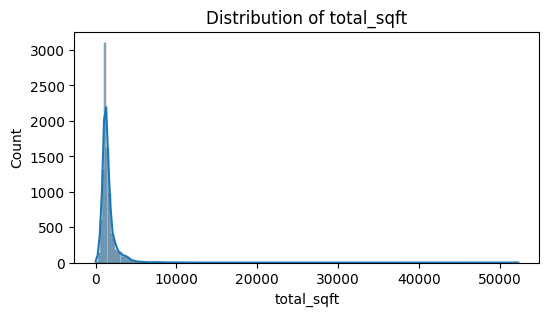

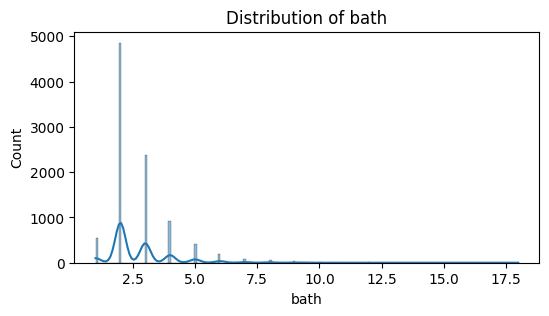

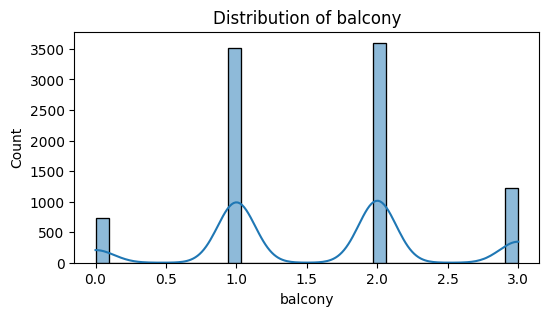

In [64]:
# sns.histplot(train_df["total_sqft"], kde=True)
for col in ["total_sqft", "bath", "balcony"]:
    plt.figure(figsize=(6, 3))
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

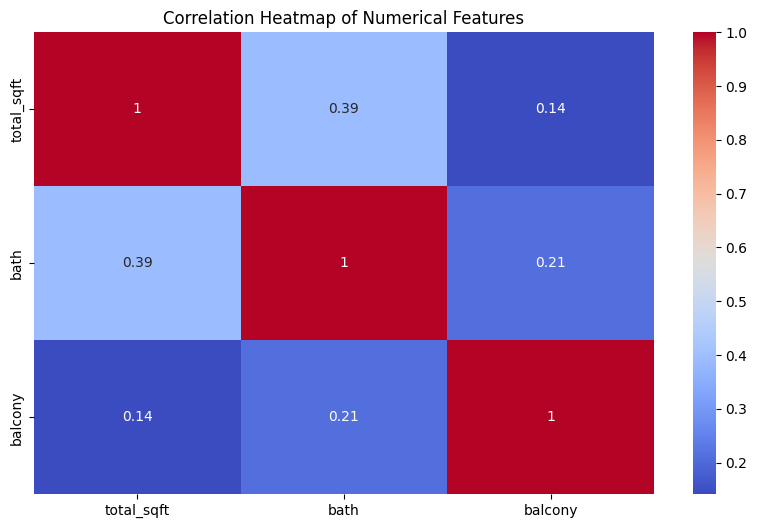

In [65]:
### Multicoll. check
plt.figure(figsize=(10, 6))
sns.heatmap(train_df[["total_sqft", "bath", "balcony"]].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

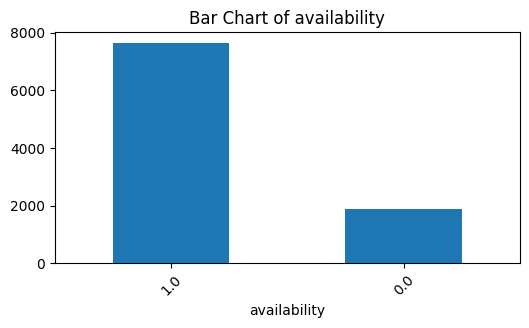

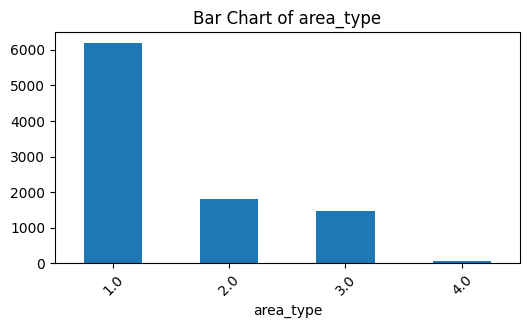

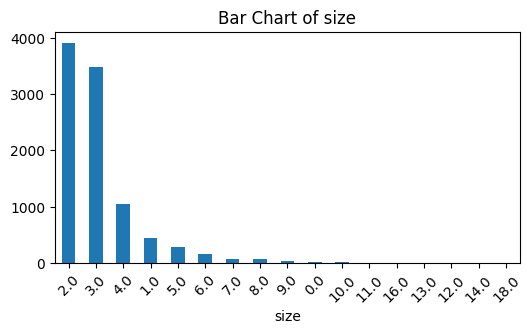

In [66]:
for col in ["availability", "area_type", "size"]:
    plt.figure(figsize=(6, 3))
    train_df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xticks(rotation=45)
    plt.show()


#### Checking outliers of each column visually

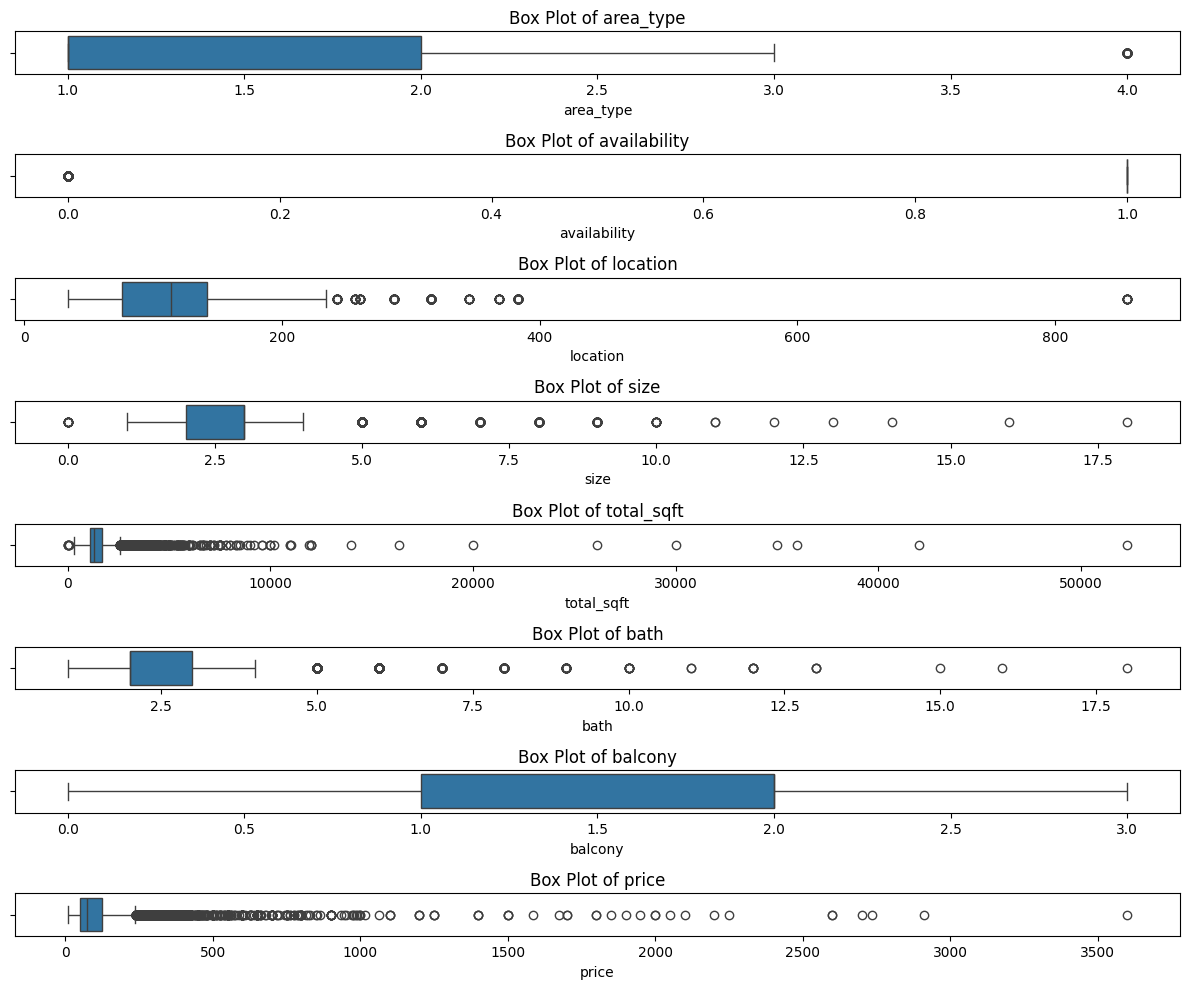

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all columns you want
cols = train_df.columns

# Create subplots
plt.figure(figsize=(12, 10))  

for i, col in enumerate(cols, 1):
    plt.subplot(len(cols), 1, i)
    sns.boxplot(x=train_df[col])
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()

plt.show()


In [68]:
def remove_outliers(df, cols):
    q1 = df[cols].quantile(0.25)
    q3 = df[cols].quantile(0.75)
    IQR = q3 - q1 
    lower_bound = q1 - (1.5*IQR)
    upper_bound = q3 + (1.5*IQR)
    filter_df = df[(df[cols]>= lower_bound) & (df[cols]<=upper_bound)]
    print(f"The number of outliers removed for cols: {cols} is {len(df)-len(filter_df)}")
    return filter_df

In [69]:
for col in ["location", "size", "total_sqft", "bath"]:
    train_df = remove_outliers(train_df, col)

The number of outliers removed for cols: location is 246
The number of outliers removed for cols: size is 616
The number of outliers removed for cols: total_sqft is 726
The number of outliers removed for cols: bath is 105


In [70]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7835 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     7835 non-null   float64
 1   availability  7835 non-null   float64
 2   location      7835 non-null   float64
 3   size          7835 non-null   float64
 4   total_sqft    7835 non-null   float64
 5   bath          7835 non-null   float64
 6   balcony       7679 non-null   float64
 7   price         7835 non-null   float64
dtypes: float64(8)
memory usage: 550.9 KB


#### Handle missing values in numerical column using SimpleImputer and scale the features

In [76]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [77]:
num_pipeline = Pipeline([
    ("Imputer", SimpleImputer(strategy="median")),
    ("standard", StandardScaler())
])


In [78]:
X_train = train_df.iloc[:,0:-1]
Y_train = train_df.iloc[:, -1]
X_test = test_df.iloc[:, 1:]

In [79]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7835 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     7835 non-null   float64
 1   availability  7835 non-null   float64
 2   location      7835 non-null   float64
 3   size          7835 non-null   float64
 4   total_sqft    7835 non-null   float64
 5   bath          7835 non-null   float64
 6   balcony       7679 non-null   float64
dtypes: float64(7)
memory usage: 489.7 KB


In [80]:
np_train = num_pipeline.fit_transform(X_train)
np_test = num_pipeline.transform(X_test)

In [81]:
model_names = []
training_score = []

### Model Fitting

#### Model 1: Simple Linear regression

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()

In [83]:
# M1 sample linear model 
model.fit(np_train, Y_train)
# train_score
train_pred = model.predict(np_train)

model_names.append("SLR")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.4531860127919157


In [85]:
predicted_val = model.predict(np_test)
result1 = pd.DataFrame({"id": range(0, len(predicted_val)), "price": predicted_val })
result1.to_csv("../outputs/simple_linear_regression.csv", index=False)

#### Model 2:  Neural Network MLP regressor

In [86]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(np_train, Y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


In [87]:
# train_score
train_pred = mlp.predict(np_train)

model_names.append("Base MLP")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.63409764329003


In [88]:
predicted_val = mlp.predict(np_test)
neural_res = pd.DataFrame({"id": range(0, len(predicted_val)), "price": predicted_val })
neural_res.to_csv("../outputs/nn_mlp_regressor.csv", index=False)

#### Model 3:  XG BOOST

In [ ]:
# ! pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 5.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 4.7 MB/s eta 0:00:00m eta 0:00:010:00:01


In [91]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.1, random_state=42)
xgb.fit(np_train, Y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [92]:
# train_score
train_pred = xgb.predict(np_train)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model_names.append("Base XGBoost")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.8535893335265319


In [94]:
predicted_val = xgb.predict(np_test)

xgb_res = pd.DataFrame({"id": range(0, len(predicted_val)), "price": predicted_val })
xgb_res.to_csv("../outputs/xgboost_regressor.csv", index=False)

#### Model 4:  Polynomial Regression

In [95]:
from sklearn.preprocessing import PolynomialFeatures

In [96]:
poly_pipe = Pipeline(
    [
    ('poly_features', PolynomialFeatures(degree=2)),
    ('linear_regression', LinearRegression())
    ]
)

In [97]:
poly_pipe.fit(np_train, Y_train)

,steps,"[('poly_features', ...), ('linear_regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [98]:
train_pred = poly_pipe.predict(np_train)
model_names.append("Poly deg 2")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.5269543393801774


In [99]:
predicted_val = poly_pipe.predict(np_test)

poly_res = pd.DataFrame({"id": range(0, len(predicted_val)), "price": predicted_val })
poly_res.to_csv("../outputs/polynomial_regressor.csv", index=False)

#### Polynomial Regression with hyper parameter tuning

In [100]:
for d in [2,3,4,5,6]:
    poly_pipe = Pipeline(
            [
            ('poly_features', PolynomialFeatures(degree=d)),
            ('linear_regression', LinearRegression())
            ]
        )
    poly_pipe.fit(np_train, Y_train)
    poly_train_pred = poly_pipe.predict(np_train)
    print(f"R2 Score: with degree {d}", r2_score(Y_train, poly_train_pred)) 

R2 Score: with degree 2 0.5269543393801774
R2 Score: with degree 3 0.5759438437073185
R2 Score: with degree 4 0.621500011352877
R2 Score: with degree 5 0.673515041030111
R2 Score: with degree 6 0.7364208573360562


In [101]:
poly_pipe4 = Pipeline(
        [
        ('poly_features', PolynomialFeatures(degree=4)),
        ('linear_regression', LinearRegression())
        ]
    )
poly_pipe4.fit(np_train, Y_train)
train_pred = poly_pipe4.predict(np_train)
model_names.append("Poly Hyper Tuned DEG 4")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.621500011352877


In [102]:
poly_test_4 = poly_pipe4.predict(np_test)
poly_res = pd.DataFrame({"id": range(0, len(poly_test_4)), "price": poly_test_4 })
poly_res.to_csv("../outputs/hyper_tuned_polynomial_regressor.csv", index=False)

#### Model 5: Ridge Regression with Hyper parameter tuning

In [104]:
from sklearn.linear_model import RidgeCV

alphas = [0.01, 0.1, 1, 10, 100]
ridge_cv = RidgeCV(alphas=alphas, scoring='r2')
ridge_cv.fit(np_train, Y_train)

print("Best alpha:", ridge_cv.alpha_)
print("Train R²:", ridge_cv.score(np_train, Y_train))


Best alpha: 10.0
Train R²: 0.45318515455767383


In [105]:
from sklearn.linear_model import Ridge
ridge_pipe = Pipeline([
    ('ridge', Ridge(alpha=10.0))
])
ridge_pipe.fit(np_train, Y_train)

,steps,"[('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,alpha,10.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False


In [106]:
train_pred = ridge_pipe.predict(np_train)
model_names.append("Ridge BASE")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.45318515455767394


In [108]:
predicted_val = ridge_pipe.predict(np_test)

rid_res = pd.DataFrame({"id": range(0, len(predicted_val)), "price": predicted_val })
rid_res.to_csv("../outputs/hyper_tuned_ridge_regressor.csv", index=False)

#### Model 6:  Random Forest Regressor

In [109]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(np_train, Y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [110]:
train_pred = rf.predict(np_train)
model_names.append("RondomForestRegress.")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.9061637081053513


In [111]:
rf_test = rf.predict(np_test)

rf_res = pd.DataFrame({"id": range(0, len(rf_test)), "price": rf_test })
rf_res.to_csv("../outputs/random_forest_regressor.csv", index=False)

#### Model 7: SVM

In [112]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(np_train, Y_train)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [113]:
train_pred = svr.predict(np_train)
model_names.append("Base SVM")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.4009342883355619


In [114]:
sv_test = svr.predict(np_test)

sv_res = pd.DataFrame({"id": range(0, len(sv_test)), "price": sv_test })
sv_res.to_csv("../outputs/support_vector_regressor.csv", index=False)

#### MLP Hyper parameter tuning Using GridSearchCV with Cross Validation

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline ensures proper scaling inside CV
mlp_pipe = Pipeline([   
    ('mlp', MLPRegressor(max_iter=3000, random_state=42))
])

# Define hyperparameter grid
param_grid = {
    'mlp__hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'mlp__activation': ['relu'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.001, 0.01],   # L2 regularization term
    'mlp__learning_rate_init': [0.01, 0.1]
}

# Cross-validation setup
grid = GridSearchCV(
    mlp_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# Fit
grid.fit(np_train, Y_train)

# Best parameters
# print("Best Parameters:", grid.best_params_)
# print("Best CV R²:", grid.best_score_)

# Evaluate on test data
best_model = grid.best_estimator_
# print("Test R²:", best_model.score(X_test, y_test))


In [116]:
mlp_final = Pipeline([
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(50,),
        activation='relu',
        solver='adam',
        alpha=0.01,
        learning_rate_init=0.01,
        max_iter=3000,               # Increased for stable convergence
        early_stopping=True,         # Stops automatically when validation loss stops improving
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

In [117]:
mlp_final.fit(np_train, Y_train)

train_pred = mlp_final.predict(np_train)
model_names.append("Hyper tuned MLP")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.5431649480384365


In [118]:
mlp_testf = mlp_final.predict(np_test)

mlp_res = pd.DataFrame({"id": range(0, len(mlp_testf)), "price": mlp_testf })
mlp_res.to_csv("../outputs/hyper_tuned_mlp_regressor.csv", index=False)

#### Polynomial Regression with Ridge

In [119]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10))
])
poly_ridge.fit(np_train, Y_train)


,steps,"[('poly', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'
,copy,True
,with_mean,True
,with_std,True


In [120]:
train_pred = poly_ridge.predict(np_train)
model_names.append("Poly with Ridge")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.5269522164231171


In [121]:
poly_rid = poly_ridge.predict(np_test)

poly_rid_res = pd.DataFrame({"id": range(0, len(poly_rid)), "price": poly_rid })
poly_rid_res.to_csv("../outputs/polynomial_ridge_regressor.csv", index=False)

# Combine Multiple model

In [122]:
from sklearn.ensemble import VotingRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

ensemble = VotingRegressor([
    ('ridge', Ridge(alpha=1.0)),
    ('mlp', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000))
])
ensemble.fit(np_train, Y_train)


,estimators,"[('ridge', ...), ('mlp', ...)]"
,weights,None
,n_jobs,None
,verbose,False
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False


In [123]:
train_pred = ensemble.predict(np_train)
model_names.append("Ensemble 1")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.5884555151710286


In [124]:
emb_test = ensemble.predict(np_test)

en_res = pd.DataFrame({"id": range(0, len(emb_test)), "price": emb_test })
en_res.to_csv("../outputs/ensemble_regressor.csv", index=False)

### More models on VotingRegressor

In [125]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

ensemble = VotingRegressor([
    ('ridge', Ridge(alpha=1.0)),
    ('mlp', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42))
])
ensemble.fit(np_train, Y_train)


,estimators,"[('ridge', ...), ('mlp', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False


In [126]:
train_pred = ensemble.predict(np_train)
model_names.append("Voting Regress.")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)

R2 Score: 0.7224776583685876


In [127]:
emb_test = ensemble.predict(np_test)

en_res = pd.DataFrame({"id": range(0, len(emb_test)), "price": emb_test })
en_res.to_csv("../outputs/ensemble_regressor2.csv", index=False)

#### ElasticNet Model

In [128]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(max_iter=10000)
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_cv = GridSearchCV(elastic, param_grid, cv=5, scoring='r2', n_jobs=-1)
elastic_cv.fit(np_train, Y_train)

print("Best Parameters:", elastic_cv.best_params_)
print("Best R²:", elastic_cv.best_score_)


Best Parameters: {'alpha': 0.1, 'l1_ratio': 0.9}
Best R²: 0.45322955878960547


In [129]:
from sklearn.ensemble import VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, ElasticNet

ensemble = VotingRegressor([
    ('elastic', ElasticNet(alpha=0.1, l1_ratio=0.9, max_iter=10000, random_state=42)),
    ('ridge', Ridge(alpha=1.0, random_state=42)),
    ('mlp', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)),
    ('rf', RandomForestRegressor(n_estimators=200, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42))
])

ensemble.fit(np_train, Y_train)

train_pred = ensemble.predict(np_train)
model_names.append("Hyper Paramter Elastic Voting Regress.")
r2_sc = r2_score(Y_train, train_pred)
training_score.append(r2_sc)
print("R2 Score:", r2_sc)


R2 Score: 0.6835385061237867


In [130]:
emb_test = ensemble.predict(np_test)

en_res = pd.DataFrame({"id": range(0, len(emb_test)), "price": emb_test })
en_res.to_csv("../outputs/ensemble_elastic_net_model.csv", index=False)

### Model Performance Comparsion

In [131]:
perf_df = pd.DataFrame({"Model Name":model_names, "Train Score": training_score})

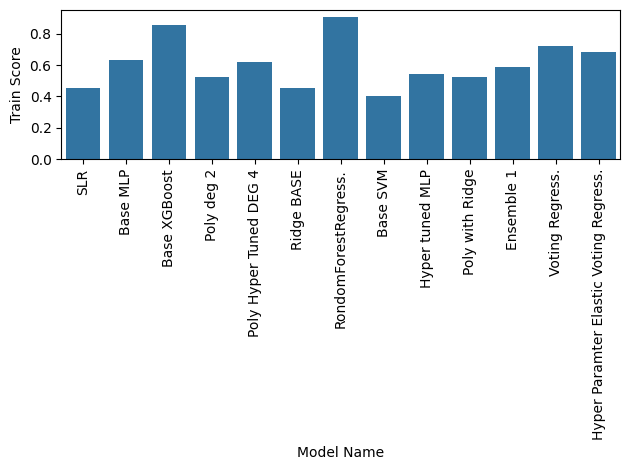

In [134]:
sns.barplot(x=perf_df["Model Name"], y=perf_df["Train Score"])
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../outputs/model_comparison.png", bbox_inches='tight')